In [14]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Porównania:
# regresja logistyczna
# SVM
# Random Forest

df = pd.read_csv('wydarzenia.csv',sep=';')
df

,Wydarzenie,Naglowek
0,BIZNES,Edukacja kluczem do osiągnięcia finansowego sp...
1,BIZNES,Nowy rozdział dla iRobot: dotychczasowy partne...
2,BIZNES,Forum Przedsiębiorczości - PARP4digital. Dokąd...
3,BIZNES,Powstała Koalicja na Rzecz Zdrowia Jamy Ustnej...
4,BIZNES,NEXT prezentuje limitowaną ofertę noworoczną
...,...,...
1270,BRAK_ZDARZENIA,Nowy dron dostawczy przeszedł pomyślnie testy ...
1271,BRAK_ZDARZENIA,Historia pierwszych polskich sukcesów na letni...
1272,BRAK_ZDARZENIA,Rozwój wirtualnych asystentów: czy zastąpią na...
1273,BRAK_ZDARZENIA,Polscy motocykliści ruszyli na wyprawę przez c...


--- ROZPOCZĘCIE EKSPERYMENTÓW ---

Wyniki dla: Logistic Regression
                precision    recall  f1-score   support

        BIZNES       0.72      0.85      0.78        67
BRAK_ZDARZENIA       0.96      0.52      0.68        52
      POLITYKA       0.85      0.97      0.91        76
       WYPADEK       0.98      1.00      0.99        60

      accuracy                           0.85       255
     macro avg       0.88      0.84      0.84       255
  weighted avg       0.87      0.85      0.85       255

------------------------------


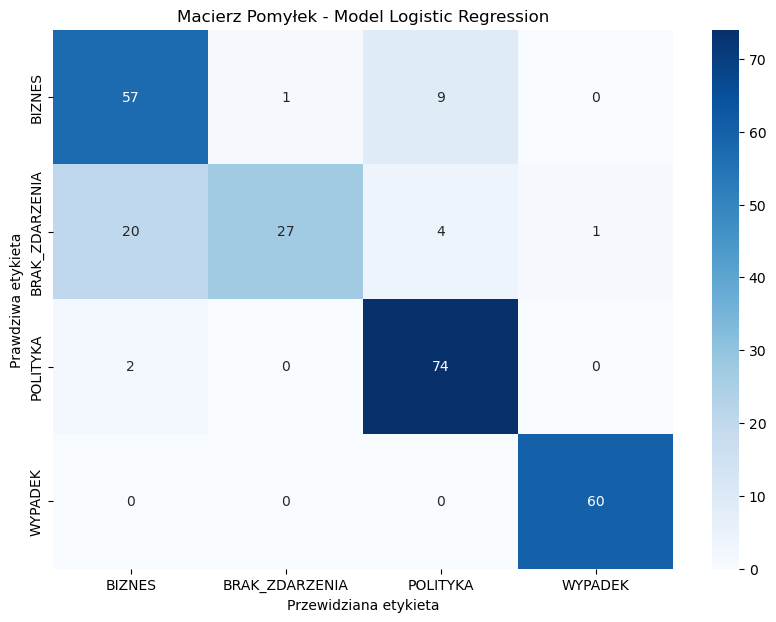

Wyniki dla: Linear SVM
                precision    recall  f1-score   support

        BIZNES       0.72      0.81      0.76        67
BRAK_ZDARZENIA       0.80      0.62      0.70        52
      POLITYKA       0.90      0.93      0.92        76
       WYPADEK       0.98      1.00      0.99        60

      accuracy                           0.85       255
     macro avg       0.85      0.84      0.84       255
  weighted avg       0.85      0.85      0.85       255

------------------------------


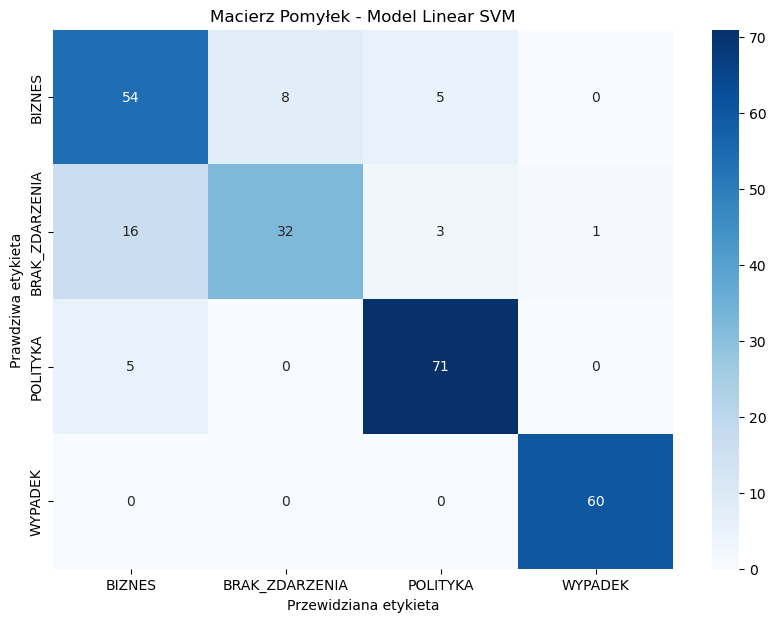

Wyniki dla: Random Forest
                precision    recall  f1-score   support

        BIZNES       0.50      0.70      0.58        67
BRAK_ZDARZENIA       0.46      0.35      0.40        52
      POLITYKA       0.89      0.72      0.80        76
       WYPADEK       1.00      1.00      1.00        60

      accuracy                           0.71       255
     macro avg       0.71      0.69      0.69       255
  weighted avg       0.73      0.71      0.71       255

------------------------------


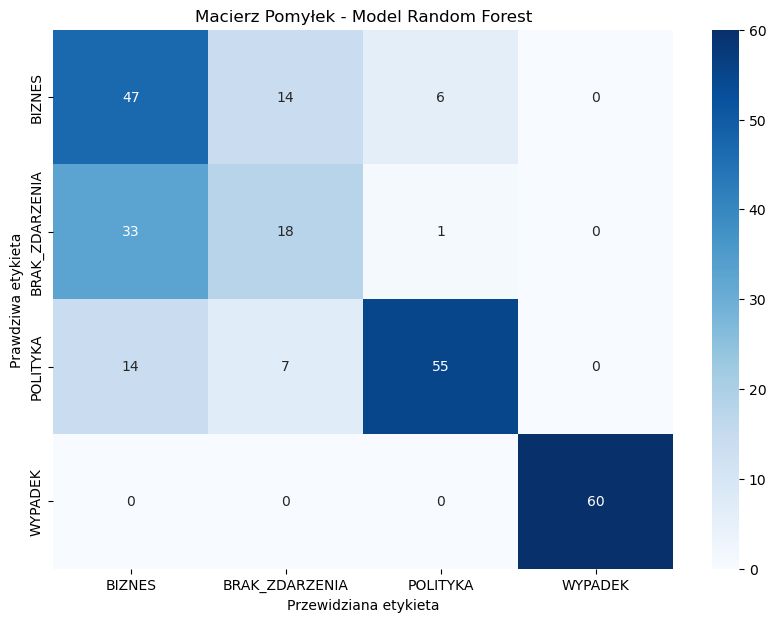


RANKING MODELI:
                 Model  F1-Score
1           Linear SVM  0.848085
0  Logistic Regression  0.846766
2        Random Forest  0.706938


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Naglowek'], df['Wydarzenie'], test_size=0.2, random_state=42, stratify=df['Wydarzenie']
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": SVC(kernel='linear', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = []
print("--- ROZPOCZĘCIE EKSPERYMENTÓW ---\n")

for name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2))), # unigramy i bigramy
        ('clf', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({"Model": name, "F1-Score": f1})
    
    print(f"Wyniki dla: {name}")
    print(classification_report(y_test, y_pred))
    print("-" * 30)
    labels = sorted(df['Wydarzenie'].unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

    plt.xlabel('Przewidziana etykieta')
    plt.ylabel('Prawdziwa etykieta')
    plt.title(f'Macierz Pomyłek - Model {name}')
    plt.show()

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\nRANKING MODELI:")
print(results_df)

# Rezultat Model SVM najlepszy 84% prawidłowej klasyfikacji

In [1]:
!python -m spacy download pl_core_news_lg

     ---------------------------------------- 0.0/573.7 MB ? eta -:--:--
     ---------------------------------------- 0.5/573.7 MB 5.6 MB/s eta 0:01:43
     ---------------------------------------- 2.1/573.7 MB 7.8 MB/s eta 0:01:14
     ---------------------------------------- 3.7/573.7 MB 7.5 MB/s eta 0:01:16
     ---------------------------------------- 5.5/573.7 MB 7.8 MB/s eta 0:01:13
      --------------------------------------- 7.3/573.7 MB 7.8 MB/s eta 0:01:13
      --------------------------------------- 8.9/573.7 MB 7.8 MB/s eta 0:01:13
      --------------------------------------- 9.7/573.7 MB 7.6 MB/s eta 0:01:14
      -------------------------------------- 12.1/573.7 MB 7.6 MB/s eta 0:01:14
      -------------------------------------- 13.6/573.7 MB 7.6 MB/s eta 0:01:14
     - ------------------------------------- 15.2/573.7 MB 7.6 MB/s eta 0:01:14
     - ------------------------------------- 17.0/573.7 MB 7.7 MB/s eta 0:01:13
     - ------------------------------------- 19

In [3]:
import spacy

nlp = spacy.load("pl_core_news_lg")

def extract_info(text):
    doc = nlp(text)
    result = {"KTO": None, "CO": None, "TRIGGER": None}
    
    for token in doc:
        # Szukamy czasownika (orzeczenia)
        if token.pos_ == "VERB":
            result["TRIGGER"] = token.lemma_ # zapisujemy formę podstawową
            
            # Szukamy dzieci tego czasownika w drzewie zależności
            for child in token.children:
                if child.dep_ == "nsubj": # Podmiot
                    result["KTO"] = child.text
                if child.dep_ in ["obj", "obl"]: # Dopełnienie
                    result["CO"] = child.text
    return result

# Test
print(extract_info("Napastnik pobił ochroniarza przed klubem"))
# Wynik: {'KTO': 'Napastnik', 'CO': 'ochroniarza', 'TRIGGER': 'pobić'}


{'KTO': 'Napastnik', 'CO': 'klubem', 'TRIGGER': 'pobić'}
